# Per-dataset sensitivity analyses (CCM revision)

Primary results in the paper are per-dataset; this notebook adds the per-dataset
sensitivity analyses requested in review, using **each dataset's own preprocessing**
(imported from its `*Util.py`).

| Analysis | Reviewer point | Datasets |
|---|---|---|
| IPW-weighted interaction test | R1 Major 1 | eICU, PMAP, MIMIC-IV (observational) |
| Lasso S-learner (penalized interactions) | R1 Major 2 | all 4 |
| GATES for neurologic outcome | R1 minor h | all 4 |
| Uniform |r|>0.7 TTM-collinearity filter | R1 minor d | eICU (confirm unchanged) |

Exposure definitions unchanged: eICU `treatment_hypothermia`; PMAP <36°C ≥12 consecutive h;
MIMIC-IV cooling device ≥12 consecutive h; HYPERION randomization.

Run on the cluster from this folder:
```bash
jupyter nbconvert --to notebook --execute perDatasetSensitivity.ipynb \
  --output perDatasetSensitivity.ipynb --ExecutePreprocessor.timeout=-1
```
Writes `per_dataset_results.csv` for the response-letter `[INSERT]` slots.


In [24]:
# CONFIG
SEED = 42
TEST_SIZE = 0.30
N_GATES_GROUPS = 5
PS_CLIP = (0.05, 0.95)
CORR_THRESHOLD = 0.7
REPO_ROOT = os.path.abspath('..')

# Predictor CSVs (the filenames the *AnalysisDML notebooks actually read).
CSV = {
    'eICU':     os.path.join(REPO_ROOT, 'eICU',     'eICUPredictorsDiag.csv'),
    'PMAP':     os.path.join(REPO_ROOT, 'pmap',     'PMAP_Predictors2.csv'),
    'MIMIC-IV': os.path.join(REPO_ROOT, 'mimiciv',  'MIMIC_Predictors.csv'),
    'HYPERION': os.path.join(REPO_ROOT, 'hyperion', 'predictorsDf.csv'),
}
DATASETS = [
    dict(name='eICU',     observational=True),
    dict(name='PMAP',     observational=True),
    dict(name='MIMIC-IV', observational=True),
    dict(name='HYPERION', observational=False),  # randomized: no IPW, unweighted GATES (Fig 3)
]

# Curated feature lists = the 'columns' each *AnalysisDML notebook trains on. Restricting to
# these (~30-40) instead of the ~1600 raw predictor columns is what keeps CausalForest and the
# lasso from overfitting (Reviewer 1 Major 2) and makes the lasso count meaningful.
CURATED = {
 'eICU': ['gender','age','bmi',
    'nurse_first_Non-Invasive BP Systolic','nurse_first_Non-Invasive BP Diastolic',
    'nurse_first_Non-Invasive BP Mean','nurse_first_Heart Rate','nurse_first_O2 Saturation',
    'lab_first_Respiratory Rate','lab_first_FiO2','nurse_first_GCS Total','nurse_first_Motor',
    'nurse_first_QTc','lab_first_pH','lab_first_paO2','lab_first_paCO2','lab_first_bicarbonate',
    'lab_first_lactate','lab_first_WBC x 1000','lab_first_Hgb','lab_first_platelets x 1000',
    'lab_first_sodium','lab_first_potassium','lab_first_BUN','lab_first_creatinine',
    'lab_first_calcium','lab_first_magnesium','lab_first_glucose','lab_first_troponin - T',
    'diagnosis_initial rhythm: ventricular fibrillation',
    'diagnosis_initial rhythm: ventricular tachycardia',
    'diagnosis_initial rhythm: pulseless electrical activity',
    'diagnosis_initial rhythm: asystole'],
 'PMAP': ['gender','age','first_mGCS','flo_first_r_cpn_glasgow_coma_scale_score',
    'flo_first_bp_systolic','flo_first_bp_diastolic','flo_first_r_map',
    'flo_first_r_ed_pre-arrival_pulse_(heart_rate)','flo_first_r_sao2','flo_first_r_fio2',
    'flo_first_r_sofa_score','flo_first_r_bmi','flo_first_r_pao2','flo_first_r_paco2',
    'flo_first_r_resp_ph','lab_first_lactate','lab_first_troponin','lab_first_hemoglobin',
    'lab_first_platelet_count','lab_first_creatinine,whole_blood','lab_first_glucose,whole_blood',
    'lab_first_potassium,whole_blood','lab_first_sodium,whole_blood','lab_first_calcium,_serum',
    'lab_first_magnesium','asystole','pea','VF'],
 'MIMIC-IV': ['gender','age','bmi','first_mGCS',
    'chart_first_heart_rate','chart_first_o2_saturation_pulseoxymetry','chart_first_respiratory_rate',
    'chart_first_fio2_(ch)','chart_first_non_invasive_blood_pressure_systolic',
    'chart_first_non_invasive_blood_pressure_diastolic','chart_first_non_invasive_blood_pressure_mean',
    'chart_first_ph_(arterial)','chart_first_arterial_o2_pressure','chart_first_arterial_co2_pressure',
    'chart_first_lactic_acid','chart_first_wbc','chart_first_hemoglobin','lab_first_platelet_count',
    'chart_first_sodium_(serum)','lab_first_potassium_(serum)','chart_first_bun',
    'chart_first_creatinine_(serum)','chart_first_calcium_non-ionized','chart_first_magnesium',
    'chart_first_glucose_(serum)','lab_first_troponin-t','chart_first_qtc',
    'long_title_ventricular_fibrillation'],
 'HYPERION': ['J0_AGE','J0_SEX','J0_BMI','J0_PAS','J0_PAD','J0_PAM','J0_FC','J0_SPO2',
    'J0_GLASGOW','J0_MOTRICE','J0_RYTHM','J0_NOFLOW','J0_LOWFLOW','J0_IGSII',
    'BIO_LEUCO','BIO_HEMO','BIO_PLAQ','BIO_SODIUM','BIO_POTAS','BIO_UREE','BIO_CREAT',
    'BIO_CALCIUM','BIO_MAGNE','BIO_GLYCEMI','BIO_LACTAT','BIO_TROPO','BIO_PH','BIO_PAO2',
    'BIO_PACO2','BIO_BICARB'],
}


In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegressionCV
from xgboost import XGBClassifier
from econml.dml import CausalForestDML

np.random.seed(SEED)
RESULTS = []


## Loaders (self-contained, restricted to the curated DML columns)

Each dataset is loaded and cohort-filtered exactly as its `*Util`/`*AnalysisDML` does, canonical
columns renamed to `TTM` / `mortality` / `neuro_favorable`, then **X is restricted to that
dataset's curated feature list** (`CURATED`). We do NOT import the `*Util.py` modules — they are
stale (wrong CSV names, a missing `top_correlations.csv`, and HYPERION uses `groupe` not a
`Hypothermia` column), which is what made the previous run fail to load PMAP/MIMIC/HYPERION.


In [26]:
UNSCORABLE = 'Unable to score due to medication'

def load_eicu():
    df = pd.read_csv(CSV['eICU'])
    f = (df['LastMGCS'] != UNSCORABLE) & (~df['LastMGCS'].isna())
    f = f & (df['FirstMGCSTime'] != df['LastMGCSTime'])
    for c in ['FirstGCS', 'FirstMGCS', 'LastMGCS', 'LastGCS']:
        df.loc[df[c] == UNSCORABLE, c] = np.nan
    df.loc[df['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    df['gender'] = (df['gender'] == 'Male').astype(int)
    df.loc[f, 'LastMGCSPositive'] = (df.loc[f, 'LastMGCS'].astype(float) == 6).astype(int)
    df = df[f & (df['nurse_first_Motor'] != 6) & ~df['Hypothermia'].isna()].copy()
    return df.rename(columns={'Hypothermia': 'TTM', 'DeathAtDischarge': 'mortality',
                              'LastMGCSPositive': 'neuro_favorable'})

def _load_epic(path):
    df = pd.read_csv(path)
    f = (df['first_mGCS_time'] != df['last_mGCS_time'])
    df.loc[df['death_at_disch'] == 1, 'last_mGCS'] = 1
    df.loc[f, 'LastMGCSPositive'] = (df.loc[f, 'last_mGCS'].astype(float) == 6).astype(int)
    df = df[(df['first_mGCS'] != 6) & ~df['hypothermia'].isna()].copy()
    return df.rename(columns={'hypothermia': 'TTM', 'death_at_disch': 'mortality',
                              'LastMGCSPositive': 'neuro_favorable'})

def load_pmap():  return _load_epic(CSV['PMAP'])
def load_mimic(): return _load_epic(CSV['MIMIC-IV'])

def load_hyperion():
    df = pd.read_csv(CSV['HYPERION'])
    df = df[df['groupe'] != 2].copy()                 # drop non-randomized/excluded arm
    df['TTM'] = (df['groupe'] == 1).astype(int)        # 1 = hypothermia, 0 = normothermia
    return df.rename(columns={'hospital_mortality': 'mortality', 'CPC12': 'neuro_favorable'})

LOADERS = {'eICU': load_eicu, 'PMAP': load_pmap, 'MIMIC-IV': load_mimic, 'HYPERION': load_hyperion}

def load_split(name, outcome_col):
    df = LOADERS[name]()
    cand = [c for c in CURATED[name] if c in df.columns]
    X = df[cand].apply(pd.to_numeric, errors='coerce')
    T = pd.to_numeric(df['TTM'], errors='coerce')
    y = pd.to_numeric(df[outcome_col], errors='coerce')
    m = T.notna() & y.notna()
    X, T, y = X[m], T[m].astype(int), y[m].astype(int)
    Xtr, Xte, Ttr, Tte, ytr, yte = train_test_split(
        X, T, y, test_size=TEST_SIZE, random_state=SEED, stratify=pd.concat([y, T], axis=1))
    r = lambda o: o.reset_index(drop=True)
    return r(Xtr), r(Xte), r(Ttr), r(Tte), r(ytr), r(yte)


def preprocess(X_tr, X_te):
    """Scale numeric (>2 levels) on train, KNN-impute (k=10) on train; apply to test."""
    keep = [c for c in X_tr.columns if X_tr[c].notna().any()]   # guard all-NaN(train) cols
    X_tr, X_te, cols = X_tr[keep], X_te[keep], keep
    num = [c for c in cols if X_tr[c].dropna().nunique() > 2]
    scaler = StandardScaler().fit(X_tr[num])
    imputer = KNNImputer(n_neighbors=10, keep_empty_features=True)

    def tf(X, fit=False):
        X = X.copy()
        if num:
            X[num] = scaler.transform(X[num])
        arr = imputer.fit_transform(X) if fit else imputer.transform(X)
        return pd.DataFrame(arr, columns=cols, index=X.index)

    return tf(X_tr, fit=True), tf(X_te)


## Shared machinery (identical to the pooled notebook)

`ipw_interaction_test` and `run_gates` are the copy-paste-ready functions referenced in the
response letter; they match the paper's GATES/propensity handling.


In [27]:
def fit_cf(X_tr, T_tr, y_tr):
    cf = CausalForestDML(
        model_y=XGBClassifier(max_depth=3, n_estimators=50),
        model_t=XGBClassifier(max_depth=2, n_estimators=20),
        discrete_treatment=True, discrete_outcome=True,
        random_state=SEED, n_jobs=-1)
    cf.fit(y_tr, T_tr, X=X_tr, cache_values=True)
    return cf


def cf_propensity(cf, X):
    preds = []
    for mc in cf.models_t:
        for mdl in mc:
            p = mdl.predict_proba(np.asarray(X))
            preds.append(p[:, 1] if p.ndim == 2 else np.ravel(p))
    return np.clip(np.mean(np.vstack(preds), axis=0), 1e-6, 1 - 1e-6)


def lrt_cate_interaction(y, T, cate):
    df = pd.DataFrame({'const': 1.0, 'T': np.asarray(T, float), 'cate': np.asarray(cate, float)})
    df['tx'] = df['T'] * df['cate']
    y = np.asarray(y, float)
    if np.ptp(df['cate']) < 1e-12:      # CATE constant -> no interaction estimable
        return {'lr_stat': np.nan, 'p': np.nan, 'note': 'CATE constant (TTM unused)'}
    m0 = sm.Logit(y, df[['const', 'T', 'cate']]).fit(disp=False)
    m1 = sm.Logit(y, df[['const', 'T', 'cate', 'tx']]).fit(disp=False)
    lr = 2 * (m1.llf - m0.llf)
    return {'lr_stat': lr, 'p': chi2.sf(lr, 1), 'note': ''}


def ipw_interaction_test(y, T, cate, ps, clip=PS_CLIP):
    # IPW weights with a ROBUST sandwich SE (cov_type='HC1') for the Wald test. var_weights
    # (the old approach) treats IPW weights as known precisions and understates the SE ->
    # anti-conservative; robust SE is the correct inference for weighted estimation.
    T = np.asarray(T, float); y = np.asarray(y, float)
    ps = np.clip(np.asarray(ps, float), *clip)
    w = np.where(T == 1, 1.0 / ps, 1.0 / (1.0 - ps))
    df = pd.DataFrame({'const': 1.0, 'T': T, 'cate': np.asarray(cate, float)})
    df['tx'] = df['T'] * df['cate']
    if np.ptp(df['cate']) < 1e-12:
        return {'wald_p': np.nan, 'wald_p_naive': np.nan}
    fam = sm.families.Binomial()
    m1 = sm.GLM(y, df[['const', 'T', 'cate', 'tx']], family=fam,
                freq_weights=w).fit(cov_type='HC1')
    m1_naive = sm.GLM(y, df[['const', 'T', 'cate', 'tx']], family=fam, var_weights=w).fit()
    return {'wald_p': m1.pvalues['tx'], 'wald_p_naive': m1_naive.pvalues['tx']}


def run_gates(cate, y, T, ps, observational, title=''):
    d = pd.DataFrame({'y': np.asarray(y, float), 'T': np.asarray(T, float),
                      'cate': np.asarray(cate, float)})
    if observational:
        ps = np.clip(np.asarray(ps, float), *PS_CLIP)
        d['w'] = np.where(d['T'] == 1, 1 / ps, 1 / (1 - ps))
    else:
        d['w'] = 1.0                      # HYPERION: unweighted OLS, as in Fig 3
    d['g'] = pd.qcut(d['cate'], q=N_GATES_GROUPS, labels=False, duplicates='drop') + 1
    rows = []
    for g, sub in d.groupby('g'):
        wls = sm.WLS(sub['y'], sm.add_constant(sub['T']), weights=sub['w']).fit()
        ci = np.asarray(wls.conf_int())
        rows.append({'group': int(g), 'n': len(sub), 'gate': wls.params.iloc[1],
                     'ci_low': ci[1, 0], 'ci_high': ci[1, 1]})
    gdf = pd.DataFrame(rows)
    gd = pd.get_dummies(d['g'].astype(int), prefix='g', drop_first=True).astype(float)
    Xr = sm.add_constant(pd.concat([d[['T']], gd], axis=1))
    Xf = Xr.copy()
    for c in gd.columns:
        Xf[f'T_x_{c}'] = d['T'].values * gd[c].values
    mf = sm.WLS(d['y'], Xf, weights=d['w']).fit()
    mr = sm.WLS(d['y'], Xr, weights=d['w']).fit()
    f_stat, f_p, _ = mf.compare_f_test(mr)
    rho, rho_p = stats.spearmanr(gdf['group'], gdf['gate'])
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.errorbar(gdf['group'], gdf['gate'],
                yerr=[gdf['gate'] - gdf['ci_low'], gdf['ci_high'] - gdf['gate']],
                fmt='o-', capsize=5)
    ax.axhline(0, ls='--', color='gray')
    ax.set_xlabel('CATE quintile'); ax.set_ylabel('GATE')
    ax.set_title(f'GATES (neuro) — {title}\nF p={f_p:.3f}, rho={rho:.2f} (p={rho_p:.3f})')
    plt.tight_layout()
    plt.savefig(f"gates_neuro_{title.lower().replace(' ', '_').replace('-', '')}.png", dpi=150)
    plt.show()
    return gdf, {'f_p': f_p, 'spearman_rho': rho, 'spearman_p': rho_p}


def lasso_slearner(X_tr, T_tr, y_tr):
    """L1 S-learner on curated features. Cs is an explicit *penalizing* grid (small C = strong
    penalty); the previous default let CV pick C=10^4 (= no penalty) on 1600+ raw features so
    every interaction survived. On the curated ~30 features this converges and the surviving-
    interaction count is meaningful (0 => no heterogeneity survives regularization)."""
    Xd = X_tr.copy()
    Xd['TTM'] = np.asarray(T_tr, float)
    inter = []
    for c in X_tr.columns:
        ic = f'{c}_x_TTM'
        Xd[ic] = Xd[c] * Xd['TTM']
        inter.append(ic)
    clf = LogisticRegressionCV(penalty='l1', solver='saga', Cs=[1e-3, 1e-2, 1e-1, 1.0],
                               cv=5, scoring='neg_log_loss', max_iter=20000,
                               n_jobs=-1, random_state=SEED)
    clf.fit(Xd, np.asarray(y_tr))
    coefs = pd.Series(clf.coef_[0], index=Xd.columns)
    nz = coefs[inter][coefs[inter] != 0]
    return len(nz), len(inter), float(clf.C_[0]), nz


## Run — datasets × outcomes

For each dataset and outcome: fit the dataset's own CausalForest, then LRT, IPW test
(observational only), GATES (neuro only, since Fig 3 already covers mortality GATES), and
the lasso S-learner. eICU additionally gets a uniform |r|>0.7 filter variant.


/local/mbranda1/3981445/ipykernel_3854183/704193395.py:4: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV['eICU'])


=== eICU / mortality: train 1289 x 33, test 553 ===
  LRT p=0.14288137557373534, IPW interaction Wald p=0.00633033492021745
  lasso: 7/33 interaction coefs survive (C=0.1)


/local/mbranda1/3981445/ipykernel_3854183/704193395.py:4: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV['eICU'])


=== eICU / neuro: train 1289 x 33, test 553 ===
  LRT p=0.9349991236410271, IPW interaction Wald p=0.6901046752750603


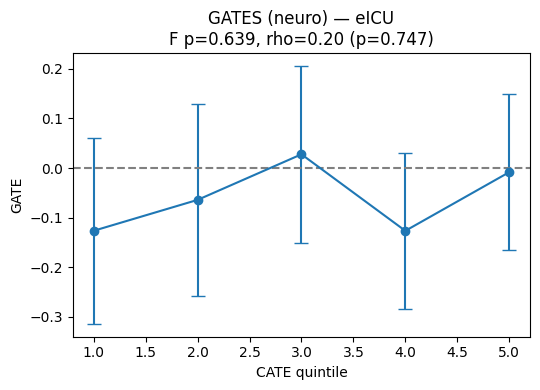

  lasso: 4/33 interaction coefs survive (C=0.1)
=== PMAP / mortality: train 988 x 26, test 424 ===
  LRT p=0.03158033469793626, IPW interaction Wald p=0.006044921396988847
  lasso: 2/26 interaction coefs survive (C=0.1)
=== PMAP / neuro: train 902 x 26, test 387 ===
  LRT p=0.983415975705108, IPW interaction Wald p=0.7937784477445542


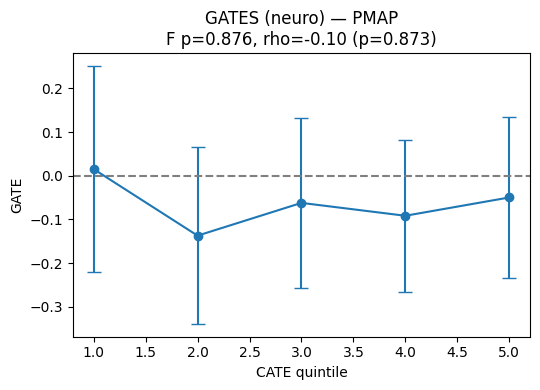

  lasso: 1/26 interaction coefs survive (C=0.1)
=== MIMIC-IV / mortality: train 427 x 24, test 184 ===
  LRT p=0.3112143929954727, IPW interaction Wald p=0.029698891997625935
  lasso: 0/24 interaction coefs survive (C=0.1)
=== MIMIC-IV / neuro: train 392 x 26, test 168 ===
  LRT p=0.46159368043077653, IPW interaction Wald p=0.6733052465193983


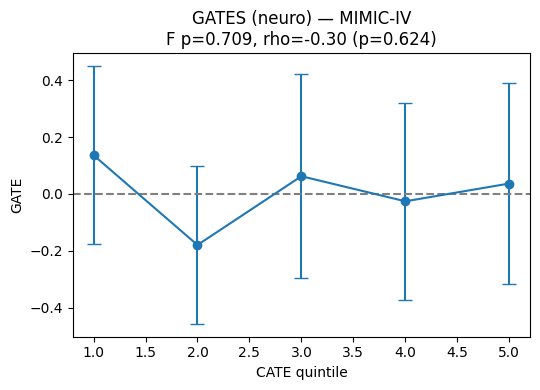

  lasso: 3/26 interaction coefs survive (C=0.1)
=== HYPERION / mortality: train 406 x 29, test 175 ===
  LRT p=0.2789977456210091 (randomized: no IPW)
  lasso: 2/29 interaction coefs survive (C=0.1)
=== HYPERION / neuro: train 406 x 29, test 175 ===
  LRT p=0.3907258669030169 (randomized: no IPW)


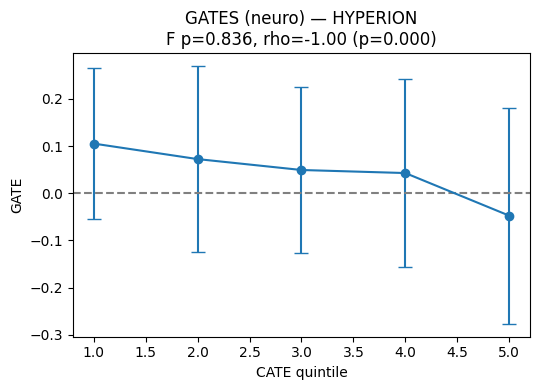

  lasso: 0/29 interaction coefs survive (C=0.1)


In [28]:
def run_one(cfg, outcome_key):
    outcome_col = 'mortality' if outcome_key == 'mortality' else 'neuro_favorable'
    label = f"{cfg['name']} / {outcome_key}"
    try:
        X_tr, X_te, T_tr, T_te, y_tr, y_te = load_split(cfg['name'], outcome_col)
    except Exception as e:
        print(f"[SKIP] {label}: load failed ({type(e).__name__}: {e})")
        RESULTS.append({'dataset': cfg['name'], 'outcome': outcome_key, 'status': f'load-fail: {e}'})
        return
    Xtr, Xte = preprocess(X_tr, X_te)
    print(f"=== {label}: train {len(Xtr)} x {Xtr.shape[1]}, test {len(Xte)} ===")

    cf = fit_cf(Xtr, T_tr, y_tr)
    cate = np.ravel(cf.effect(Xte))
    lrt = lrt_cate_interaction(y_te, T_te, cate)
    row = {'dataset': cfg['name'], 'outcome': outcome_key, 'status': 'ok',
           'n_train': len(Xtr), 'n_features': Xtr.shape[1],
           'lrt_p': lrt['p'], 'lrt_note': lrt.get('note', '')}

    if cfg['observational']:
        ps = cf_propensity(cf, Xte)
        ipw = ipw_interaction_test(y_te, T_te, cate, ps)
        row['ipw_wald_p'] = ipw['wald_p']; row['ipw_wald_p_naive'] = ipw['wald_p_naive']
        print(f"  LRT p={lrt['p']}, IPW interaction Wald p={ipw['wald_p']}")
    else:
        ps = None
        print(f"  LRT p={lrt['p']} (randomized: no IPW)")

    if outcome_key == 'neuro':
        gdf, g = run_gates(cate, y_te, T_te, ps, cfg['observational'], title=cfg['name'])
        row['gates_neuro_f_p'] = g['f_p']
        row['gates_neuro_spearman_rho'] = g['spearman_rho']
        row['gates_neuro_spearman_p'] = g['spearman_p']

    n_nz, n_int, C, nz = lasso_slearner(Xtr, T_tr, y_tr)
    row['lasso_nonzero_interactions'] = n_nz; row['lasso_n_interactions'] = n_int
    row['lasso_C'] = C
    print(f"  lasso: {n_nz}/{n_int} interaction coefs survive (C={C:.4g})")
    RESULTS.append(row)


for cfg in DATASETS:
    for outcome_key in ['mortality', 'neuro']:
        run_one(cfg, outcome_key)


## eICU uniform collinearity filter (R1 minor d)

Reviewer 1 asked why balance is tighter in PMAP/MIMIC (which drop covariates with
|r|>0.7 vs TTM) than in eICU (which does not). Here we apply the same filter to eICU and
confirm the HTE conclusion is unchanged.


In [29]:
def run_eicu_uniform_filter(outcome_key='mortality'):
    outcome_col = 'mortality' if outcome_key == 'mortality' else 'neuro_favorable'
    X_tr, X_te, T_tr, T_te, y_tr, y_te = load_split('eICU', outcome_col)
    corr = X_tr.apply(lambda c: np.corrcoef(c.fillna(c.median()), T_tr)[0, 1]).abs()
    drop = corr[corr > CORR_THRESHOLD].index.tolist()
    print(f"eICU |r|>{CORR_THRESHOLD} with TTM -> dropping {len(drop)}: {drop}")
    keep = [c for c in X_tr.columns if c not in drop]
    Xtr, Xte = preprocess(X_tr[keep], X_te[keep])
    cf = fit_cf(Xtr, T_tr, y_tr)
    cate = np.ravel(cf.effect(Xte))
    lrt = lrt_cate_interaction(y_te, T_te, cate)
    ps = cf_propensity(cf, Xte)
    ipw = ipw_interaction_test(y_te, T_te, cate, ps)
    print(f"  after filter: LRT p={lrt['p']}, IPW Wald p={ipw['wald_p']}")
    RESULTS.append({'dataset': 'eICU (|r|>0.7 filter)', 'outcome': outcome_key, 'status': 'ok',
                    'n_features': len(keep), 'lrt_p': lrt['p'], 'ipw_wald_p': ipw['wald_p'],
                    'lrt_note': f'dropped {len(drop)} collinear'})

run_eicu_uniform_filter('mortality')


/local/mbranda1/3981445/ipykernel_3854183/704193395.py:4: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV['eICU'])


eICU |r|>0.7 with TTM -> dropping 0: []
  after filter: LRT p=0.14288137557373534, IPW Wald p=0.006330334920217442


## Summary for the response letter

In [30]:
summary = pd.DataFrame(RESULTS)
summary.to_csv('per_dataset_results.csv', index=False)
display(summary.round(4))

print('\n--- Paste-ready ---')
ok = summary[summary['status'] == 'ok']
for _, r in ok.iterrows():
    bits = [f"LRT p={r.get('lrt_p')}"]
    if pd.notna(r.get('ipw_wald_p')):        bits.append(f"IPW p={r.get('ipw_wald_p'):.3f}")
    if pd.notna(r.get('gates_neuro_f_p')):   bits.append(f"GATES-neuro F p={r.get('gates_neuro_f_p'):.3f}")
    if pd.notna(r.get('lasso_nonzero_interactions')):
        bits.append(f"lasso {int(r['lasso_nonzero_interactions'])}/{int(r['lasso_n_interactions'])} interactions")
    print(f"{r['dataset']:24s} {r['outcome']:9s}: " + '; '.join(str(b) for b in bits))


,dataset,outcome,status,n_train,n_features,lrt_p,lrt_note,ipw_wald_p,ipw_wald_p_naive,lasso_nonzero_interactions,lasso_n_interactions,lasso_C,gates_neuro_f_p,gates_neuro_spearman_rho,gates_neuro_spearman_p
0,eICU,mortality,ok,1289.0,33,0.1429,,0.0063,0.0054,7.0,33.0,0.1,NaN,NaN,NaN
1,eICU,neuro,ok,1289.0,33,0.9350,,0.6901,0.6931,4.0,33.0,0.1,0.6395,0.2,0.7471
2,PMAP,mortality,ok,988.0,26,0.0316,,0.0060,0.0060,2.0,26.0,0.1,NaN,NaN,NaN
3,PMAP,neuro,ok,902.0,26,0.9834,,0.7938,0.7752,1.0,26.0,0.1,0.8758,-0.1,0.8729
4,MIMIC-IV,mortality,ok,427.0,24,0.3112,,0.0297,0.0321,0.0,24.0,0.1,NaN,NaN,NaN
5,MIMIC-IV,neuro,ok,392.0,26,0.4616,,0.6733,0.6538,3.0,26.0,0.1,0.7094,-0.3,0.6238
6,HYPERION,mortality,ok,406.0,29,0.2790,,NaN,NaN,2.0,29.0,0.1,NaN,NaN,NaN
7,HYPERION,neuro,ok,406.0,29,0.3907,,NaN,NaN,0.0,29.0,0.1,0.8362,-1.0,0.0000
8,eICU (|r|>0.7 filter),mortality,ok,NaN,33,0.1429,dropped 0 collinear,0.0063,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Paste-ready ---
eICU                     mortality: LRT p=0.14288137557373534; IPW p=0.006; lasso 7/33 interactions
eICU                     neuro    : LRT p=0.9349991236410271; IPW p=0.690; GATES-neuro F p=0.639; lasso 4/33 interactions
PMAP                     mortality: LRT p=0.03158033469793626; IPW p=0.006; lasso 2/26 interactions
PMAP                     neuro    : LRT p=0.983415975705108; IPW p=0.794; GATES-neuro F p=0.876; lasso 1/26 interactions
MIMIC-IV                 mortality: LRT p=0.3112143929954727; IPW p=0.030; lasso 0/24 interactions
MIMIC-IV                 neuro    : LRT p=0.46159368043077653; IPW p=0.673; GATES-neuro F p=0.709; lasso 3/26 interactions
HYPERION                 mortality: LRT p=0.2789977456210091; lasso 2/29 interactions
HYPERION                 neuro    : LRT p=0.3907258669030169; GATES-neuro F p=0.836; lasso 0/29 interactions
eICU (|r|>0.7 filter)    mortality: LRT p=0.14288137557373534; IPW p=0.006
